# 1.2 Вариационный вывод с полноранговой ковариационной матрицей

Модель использует разложение Холецкого через `LKJCholesky`, а guide — `AutoMultivariateNormal`  
(вместо `AutoDiagonalNormal` из 1.1).

Это позволяет VI улавливать **корреляции** между измерениями — критично для кластера B.

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoMultivariateNormal, init_to_median

from sklearn.cluster import KMeans
from scipy.stats import chi2

### Генерация данных (те же данные, что в 1.1)

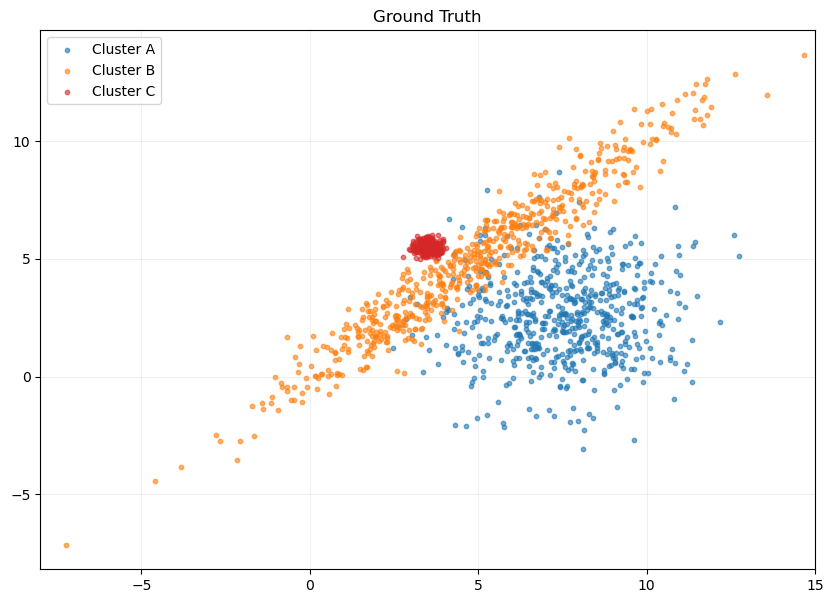

In [6]:
def generate_complex_gmm_data_with_labels(n_samples=1500):
    torch.manual_seed(42)
    loc_a = torch.tensor([7.5, 2.5])
    data_a = torch.randn(600, 2) * 1.8 + loc_a
    labels_a = torch.zeros(600)

    loc_b = torch.tensor([5.0, 5.0])
    scale_b = torch.tensor([4.5, 0.6])
    theta = torch.tensor([torch.pi / 4])
    rot = torch.tensor([[theta.cos(), -theta.sin()], [theta.sin(), theta.cos()]])
    data_b = (torch.randn(600, 2) * scale_b) @ rot.T + loc_b
    labels_b = torch.ones(600)

    loc_c = torch.tensor([3.5, 5.5])
    data_c = torch.randn(300, 2) * 0.2 + loc_c
    labels_c = torch.ones(300) * 2

    data = torch.cat([data_a, data_b, data_c])
    labels = torch.cat([labels_a, labels_b, labels_c])
    idx = torch.randperm(n_samples)
    return data[idx], labels[idx]


data_2d, true_labels = generate_complex_gmm_data_with_labels()

plt.figure(figsize=(10, 7))
colors_gt = ['#1f77b4', '#ff7f0e', '#d62728']
for i, lbl in enumerate(['A', 'B', 'C']):
    mask = (true_labels == i)
    plt.scatter(data_2d[mask, 0], data_2d[mask, 1],
                s=10, alpha=0.6, c=colors_gt[i], label=f'Cluster {lbl}')
plt.title('Ground Truth')
plt.legend()
plt.xlim(-8, 15)
plt.grid(True, alpha=0.2)
plt.show()

---
## Модель с полной матрицей ковариации


In [7]:
def model_fr(data, K=3):
    D = data.shape[1]
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K)))

    with pyro.plate("components", K):
       
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 10.0).to_event(1))

       
        scales = pyro.sample("scales", dist.LogNormal(torch.zeros(D), 2.0).to_event(1)) + 0.01

        # LKJCholesky задаёт корреляционную матрицу:
        # concentration=1.0 соответствует равномерному распределению по корреляциям
        corr_cholesky = pyro.sample("corr_cholesky", dist.LKJCholesky(D, concentration=1.0))

        # Сборка полной нижнетреугольной матрицы Холецкого:
        # L = diag(scales) @ corr_cholesky
        # Это стандартный способ параметризовать полную ковариацию через LKJ
        L = torch.matmul(torch.diag_embed(scales), corr_cholesky)

    with pyro.plate("data", len(data)):
        pyro.sample(
            "obs",
            dist.MixtureSameFamily(
                dist.Categorical(weights),
                dist.MultivariateNormal(locs, scale_tril=L)
            ),
            obs=data
        )

---
## Вспомогательная функция: 2-sigma эллипсы для полной ковариации

Теперь эллипсы могут быть **повёрнуты**.

In [8]:
def plot_full_cov_ellipses(ax, locs, scale_trils, weights, color, alpha=0.85, label_prefix=''):
    """
    Рисует 2-sigma эллипсы для GMM с полной матрицей ковариации.
    
    locs:        (K, D)    — центры кластеров
    scale_trils: (K, D, D) — матрицы Холецкого L, такие что Sigma = L @ L.T
    weights:     (K,)      — веса кластеров
    """
    K = locs.shape[0]
    for k in range(K):
        mu = locs[k]          
        L  = scale_trils[k]   
        w  = weights[k]

        # Ковариационная матрица: Sigma = L @ L.T
        Sigma = L @ L.T       

        
        eigvals, eigvecs = np.linalg.eigh(Sigma)  
        # Сортируем по убыванию (наибольшее собственное значение = главная ось)
        order = np.argsort(eigvals)[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]

        # Угол поворота главной оси (в градусах)
        angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

        width  = 4 * np.sqrt(eigvals[0])  # 4 = 2 * 2sigma
        height = 4 * np.sqrt(eigvals[1])

        ellipse_fill = patches.Ellipse(
            xy=mu, width=width, height=height, angle=angle,
            edgecolor='none', facecolor=color, alpha=0.13
        )
        ax.add_patch(ellipse_fill)
        # Контур
        ellipse_edge = patches.Ellipse(
            xy=mu, width=width, height=height, angle=angle,
            edgecolor=color, facecolor='none', linewidth=2, alpha=alpha
        )
        ax.add_patch(ellipse_edge)
        ax.scatter(*mu, s=40, marker='x', color=color, zorder=5, linewidth=1.5)
        ax.annotate(f'{label_prefix}k{k+1} w={w:.2f}',
                    xy=mu, fontsize=7.5, ha='center', va='bottom',
                    color=color, fontweight='bold')

---
## Часть 1: init_to_median (5 запусков)



Run 1: 16.02s | final ELBO = 6330.5
Run 2: 16.65s | final ELBO = 7390.6
Run 3: 15.69s | final ELBO = 6900.9
Run 4: 15.75s | final ELBO = 6847.0
Run 5: 16.30s | final ELBO = 6971.5


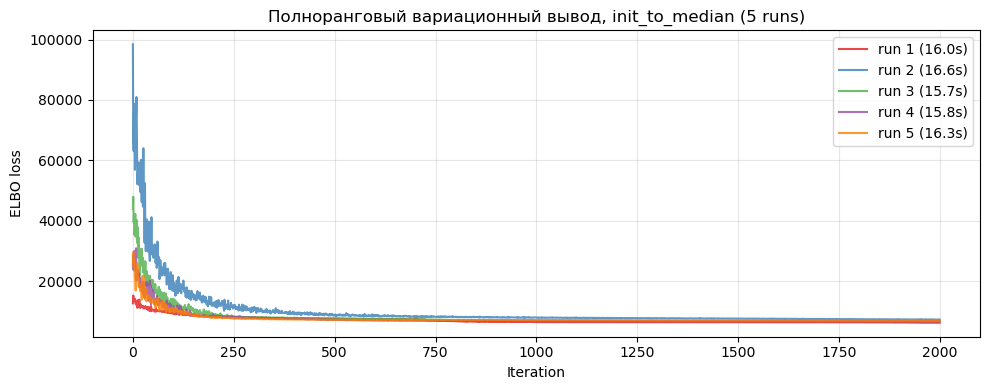


Среднее время одного запуска: 16.08s


In [17]:
N_RUNS  = 5
N_STEPS = 2000
K = 3
run_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

results_default = []

plt.figure(figsize=(10, 4))

for i in range(N_RUNS):
    pyro.clear_param_store()
    torch.manual_seed(42 * (i + 1))

    # AutoMultivariateNormal — Full Rank VI
    # Аппроксимирует весь вектор параметров одним многомерным нормальным распределением
    guide = AutoMultivariateNormal(model_fr, init_loc_fn=init_to_median)
    optimizer = pyro.optim.Adam({'lr': 0.01})
    svi = SVI(model_fr, guide, optimizer, loss=Trace_ELBO())

    elbo_trace = []
    t0 = time.time()
    for step in range(N_STEPS):
        loss = svi.step(data_2d)
        elbo_trace.append(loss)
    elapsed = time.time() - t0

    # Семплируем из обученного guide для оценки апостериора
    with torch.no_grad():
        samples = {'weights': [], 'locs': [], 'scales': [], 'corr_cholesky': []}
        for _ in range(300):
            s = guide(data_2d)
            for k in samples:
                samples[k].append(s[k])
        post = {k: torch.stack(v).mean(0) for k, v in samples.items()}

    # Восстанавливаем матрицы L = diag(scales) @ corr_cholesky
    scales_np  = post['scales'].numpy()          # (K, 2)
    corr_L_np  = post['corr_cholesky'].numpy()   # (K, 2, 2)
    L_matrices = np.einsum('ki,kij->kij', scales_np, corr_L_np)  # (K, 2, 2)

    results_default.append({
        'locs':    post['locs'].numpy(),
        'L':       L_matrices,
        'weights': post['weights'].numpy(),
        'elbo':    elbo_trace,
        'time':    elapsed
    })

    plt.plot(elbo_trace, color=run_colors[i], label=f'run {i+1} ({elapsed:.1f}s)', alpha=0.8)
    print(f"Run {i+1}: {elapsed:.2f}s | final ELBO = {elbo_trace[-1]:.1f}")

plt.title('Полноранговый вариационный вывод, init_to_median (5 runs)')
plt.xlabel('Iteration')
plt.ylabel('ELBO loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nСреднее время одного запуска: {np.mean([r['time'] for r in results_default]):.2f}s")

### Визуализация: init_to_median — 2-sigma эллипсы (повёрнутые)

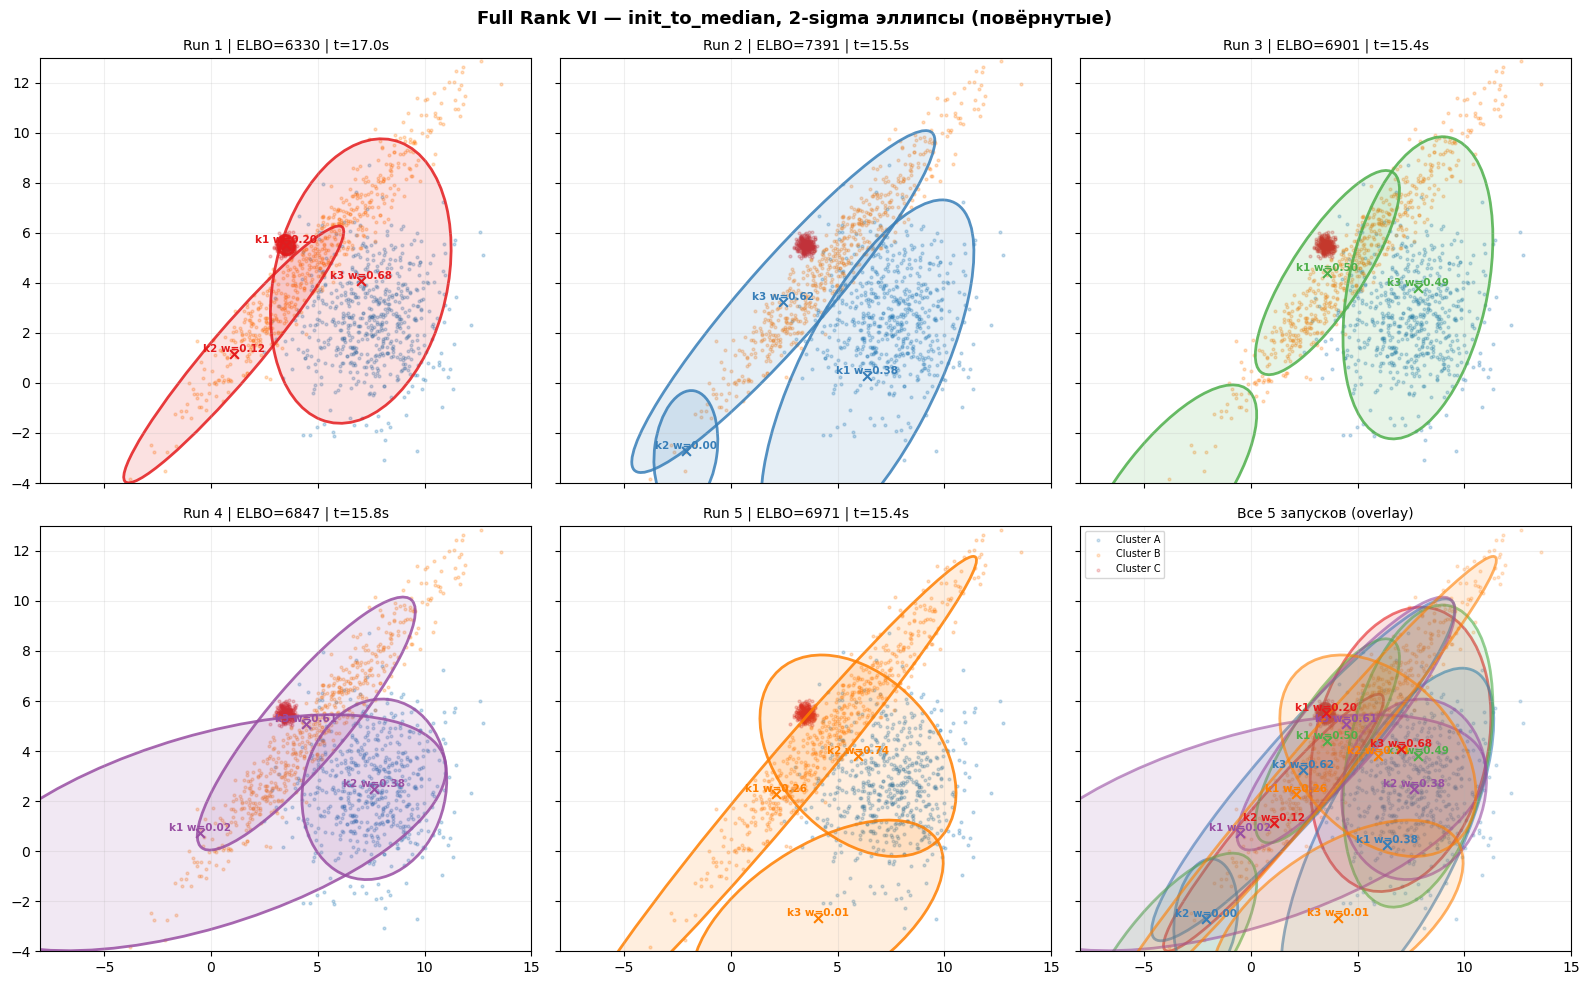

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, res in enumerate(results_default):
    ax = axes[i]
    for cls, c in enumerate(colors_gt):
        mask = (true_labels == cls)
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=4, alpha=0.25, c=c)

    plot_full_cov_ellipses(
        ax,
        locs=res['locs'],
        scale_trils=res['L'],
        weights=res['weights'],
        color=run_colors[i]
    )
    ax.set_title(f'Run {i+1} | ELBO={res["elbo"][-1]:.0f} | t={res["time"]:.1f}s', fontsize=10)
    ax.set_xlim(-8, 15); ax.set_ylim(-4, 13)
    ax.grid(True, alpha=0.2)

# Overlay всех запусков
ax = axes[5]
for cls, (c, lbl) in enumerate(zip(colors_gt, ['A', 'B', 'C'])):
    mask = (true_labels == cls)
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=4, alpha=0.2, c=c, label=f'Cluster {lbl}')
for i, res in enumerate(results_default):
    plot_full_cov_ellipses(ax, res['locs'], res['L'], res['weights'],
                           color=run_colors[i], alpha=0.6)
ax.set_title('Все 5 запусков (overlay)', fontsize=10)
ax.set_xlim(-8, 15); ax.set_ylim(-4, 13)
ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

fig.suptitle('Full Rank VI — init_to_median, 2-sigma эллипсы (повёрнутые)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Часть 2: K-means инициализация


In [11]:
# K-means на данных
data_np = data_2d.numpy()
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(data_np)

km_centers = kmeans.cluster_centers_     # (K, 2)
km_labels  = kmeans.labels_
km_stds    = np.array([data_np[km_labels == k].std(axis=0) for k in range(K)])  # (K, 2)
km_weights = np.array([(km_labels == k).mean() for k in range(K)])

print("Centers:\n", km_centers)
print("Stds:\n", km_stds)
print("Weights:", km_weights)

Centers:
 [[3.2797215 3.9455166]
 [7.8258905 2.0096054]
 [7.963109  7.4137945]]
Stds:
 [[1.5122505 1.9835548]
 [1.4467251 1.5163726]
 [1.7671548 1.932767 ]]
Weights: [0.488      0.30533333 0.20666667]


In [12]:
def kmeans_init_fn_fr(site):
    """
    K-means инициализация для model_fr.
    corr_cholesky инициализируется единичной матрицей — "нет корреляции".
    Это разумная нейтральная точка старта; оптимизация сама найдёт корреляции.
    """
    if site['name'] == 'locs':
        return torch.tensor(km_centers, dtype=torch.float32)
    if site['name'] == 'scales':
        return torch.tensor(km_stds + 1e-3, dtype=torch.float32)
    if site['name'] == 'weights':
        return torch.tensor(km_weights, dtype=torch.float32)
    if site['name'] == 'corr_cholesky':
        # Единичная нижнетреугольная матрица для каждого кластера
        # = нет начальной корреляции между признаками
        return torch.eye(2).unsqueeze(0).expand(K, -1, -1).clone()
    return init_to_median(site)

Run 1: 15.64s | final ELBO = 6050.3
Run 2: 15.58s | final ELBO = 6054.7
Run 3: 15.70s | final ELBO = 6052.3
Run 4: 15.67s | final ELBO = 6052.3
Run 5: 15.59s | final ELBO = 6057.8


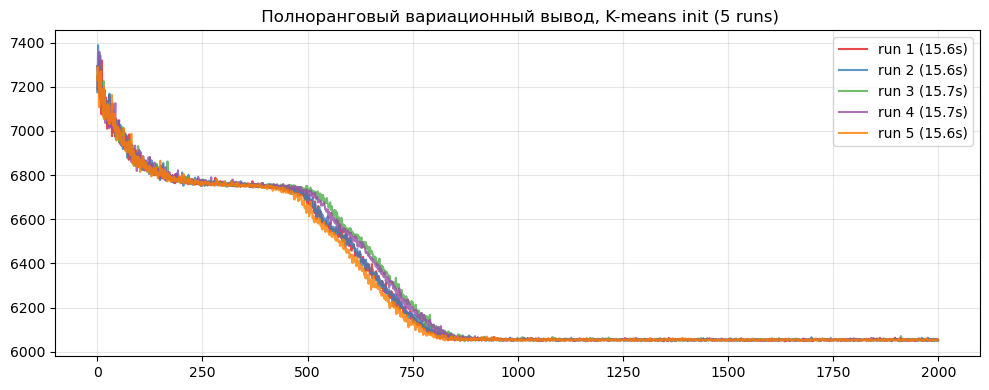


Среднее время одного запуска: 15.63s


In [16]:
results_kmeans = []

plt.figure(figsize=(10, 4))

for i in range(N_RUNS):
    pyro.clear_param_store()
    torch.manual_seed(42 * (i + 1))

    guide = AutoMultivariateNormal(model_fr, init_loc_fn=kmeans_init_fn_fr)
    optimizer = pyro.optim.Adam({'lr': 0.01})
    svi = SVI(model_fr, guide, optimizer, loss=Trace_ELBO())

    elbo_trace = []
    t0 = time.time()
    for step in range(N_STEPS):
        loss = svi.step(data_2d)
        elbo_trace.append(loss)
    elapsed = time.time() - t0

    with torch.no_grad():
        samples = {'weights': [], 'locs': [], 'scales': [], 'corr_cholesky': []}
        for _ in range(300):
            s = guide(data_2d)
            for k in samples:
                samples[k].append(s[k])
        post = {k: torch.stack(v).mean(0) for k, v in samples.items()}

    scales_np = post['scales'].numpy()
    corr_L_np = post['corr_cholesky'].numpy()
    L_matrices = np.einsum('ki,kij->kij', scales_np, corr_L_np)

    results_kmeans.append({
        'locs':    post['locs'].numpy(),
        'L':       L_matrices,
        'weights': post['weights'].numpy(),
        'elbo':    elbo_trace,
        'time':    elapsed
    })

    plt.plot(elbo_trace, color=run_colors[i], label=f'run {i+1} ({elapsed:.1f}s)', alpha=0.8)
    print(f"Run {i+1}: {elapsed:.2f}s | final ELBO = {elbo_trace[-1]:.1f}")

plt.title(' Полноранговый вариационный вывод, K-means init (5 runs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nСреднее время одного запуска: {np.mean([r['time'] for r in results_kmeans]):.2f}s")

### Визуализация: K-means init — 2-sigma эллипсы

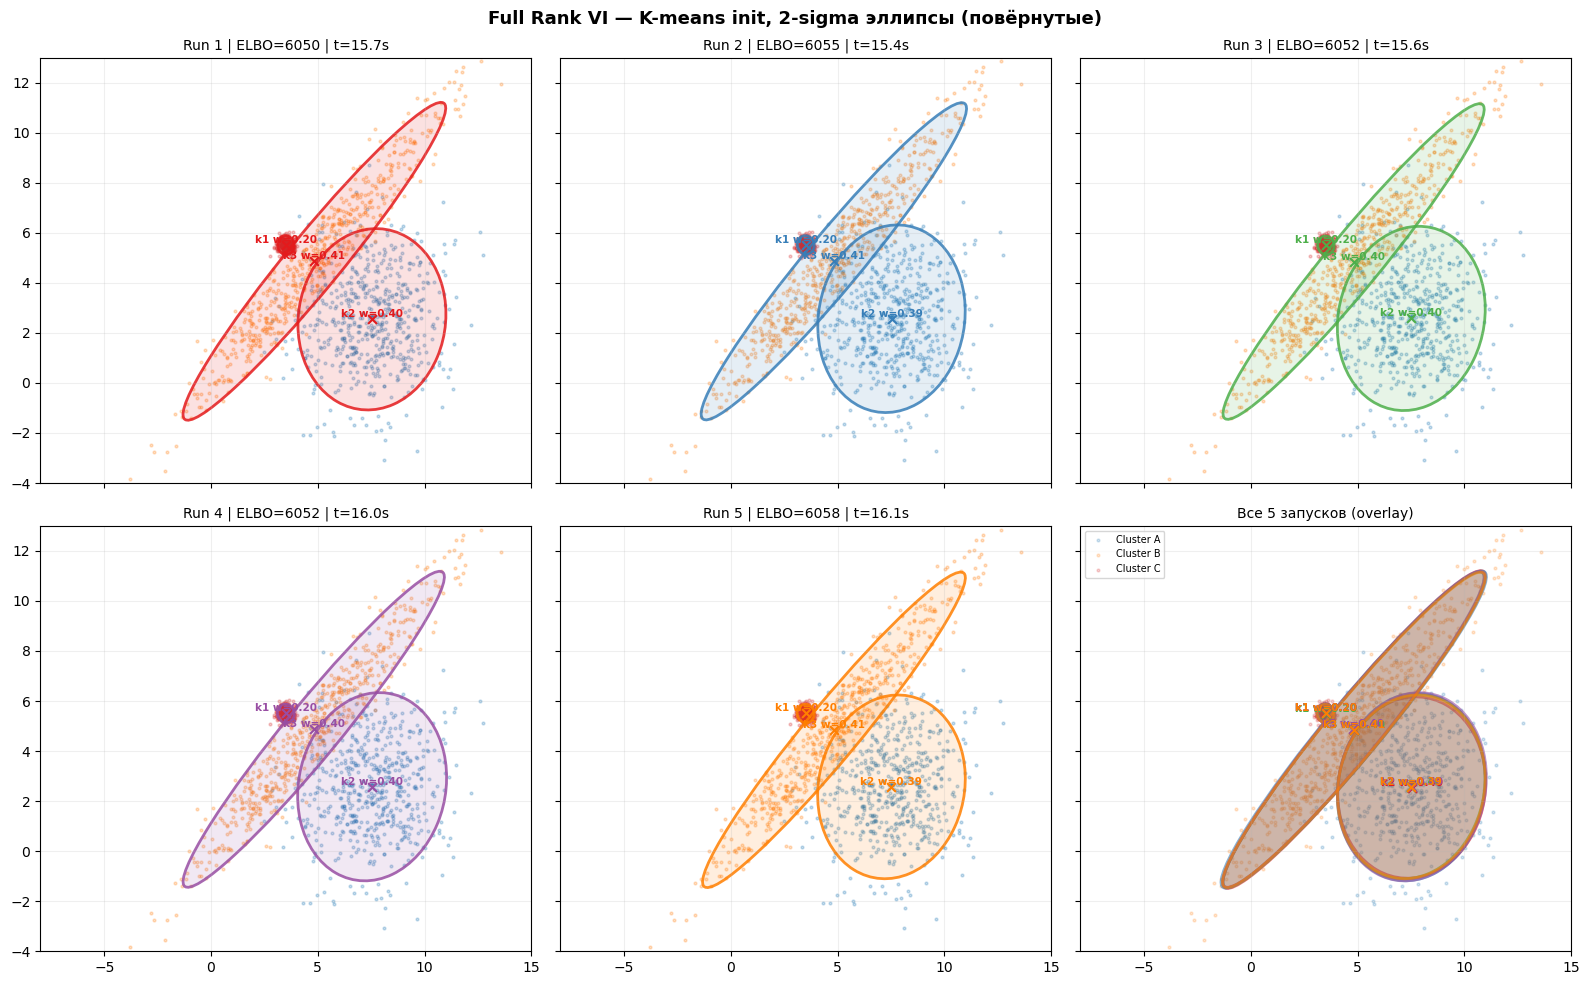

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, res in enumerate(results_kmeans):
    ax = axes[i]
    for cls, c in enumerate(colors_gt):
        mask = (true_labels == cls)
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=4, alpha=0.25, c=c)
    plot_full_cov_ellipses(ax, res['locs'], res['L'], res['weights'], color=run_colors[i])
    ax.set_title(f'Run {i+1} | ELBO={res["elbo"][-1]:.0f} | t={res["time"]:.1f}s', fontsize=10)
    ax.set_xlim(-8, 15); ax.set_ylim(-4, 13)
    ax.grid(True, alpha=0.2)

ax = axes[5]
for cls, (c, lbl) in enumerate(zip(colors_gt, ['A', 'B', 'C'])):
    mask = (true_labels == cls)
    ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=4, alpha=0.2, c=c, label=f'Cluster {lbl}')
for i, res in enumerate(results_kmeans):
    plot_full_cov_ellipses(ax, res['locs'], res['L'], res['weights'],
                           color=run_colors[i], alpha=0.6)
ax.set_title('Все 5 запусков (overlay)', fontsize=10)
ax.set_xlim(-8, 15); ax.set_ylim(-4, 13)
ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

fig.suptitle('K-means init, 2-sigma эллипсы (повёрнутые)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Итоговое сравнение: 1.1 (Mean Field) vs 1.2 (Full Rank)

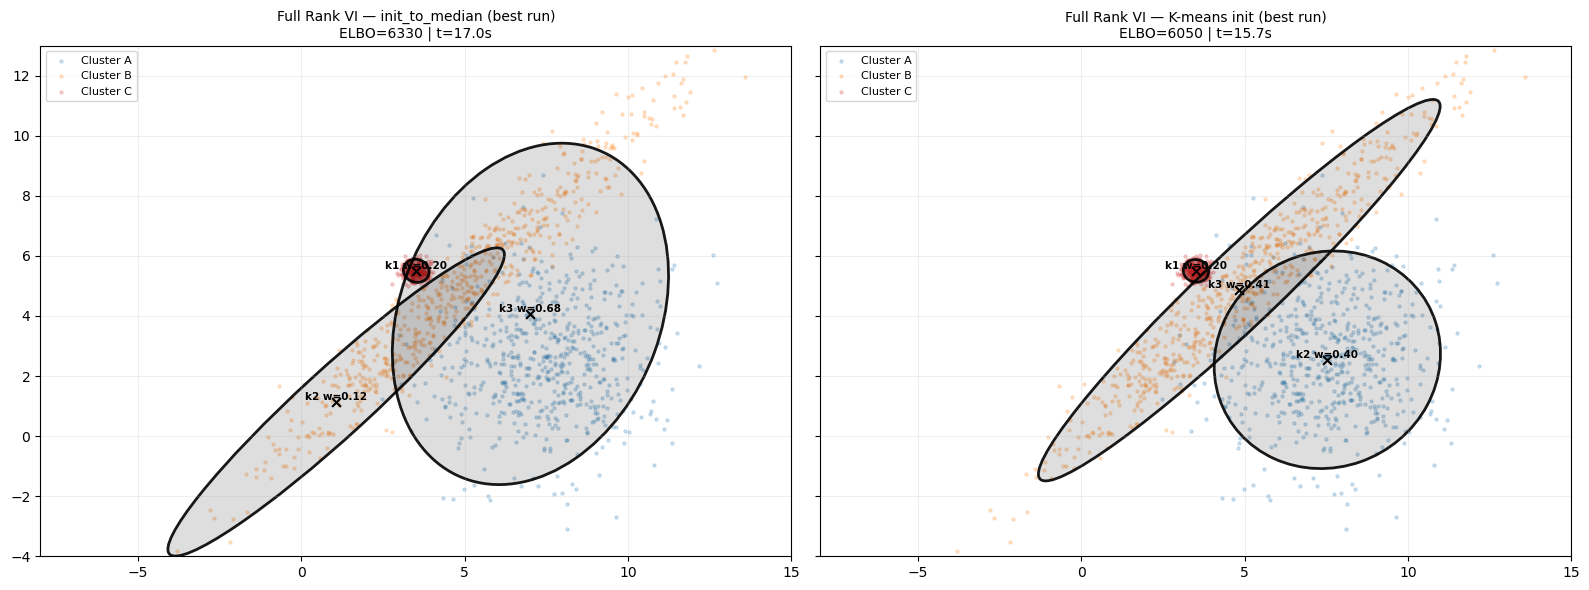

Среднее время (Full Rank VI):
  init_to_median : 15.83s
  K-means init   : 15.74s

Дисперсия ELBO (устойчивость):
  init_to_median : 338.3
  K-means init   : 2.6


In [15]:
# Берём лучший run по ELBO для каждого метода
best_default = min(results_default, key=lambda r: r['elbo'][-1])
best_kmeans  = min(results_kmeans,  key=lambda r: r['elbo'][-1])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

titles = ['init_to_median (best run)',
          'K-means init (best run)']
bests  = [best_default, best_kmeans]

for ax, title, res in zip(axes, titles, bests):
    for cls, (c, lbl) in enumerate(zip(colors_gt, ['A', 'B', 'C'])):
        mask = (true_labels == cls)
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1], s=5, alpha=0.2, c=c, label=f'Cluster {lbl}')
    plot_full_cov_ellipses(ax, res['locs'], res['L'], res['weights'], color='black', alpha=0.9)
    ax.set_title(f'{title}\nELBO={res["elbo"][-1]:.0f} | t={res["time"]:.1f}s', fontsize=10)
    ax.set_xlim(-8, 15); ax.set_ylim(-4, 13)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print("Среднее время:")
print(f"  init_to_median : {np.mean([r['time'] for r in results_default]):.2f}s")
print(f"  K-means init   : {np.mean([r['time'] for r in results_kmeans]):.2f}s")
print("\nДисперсия ELBO (устойчивость):")
print(f"  init_to_median : {np.std([r['elbo'][-1] for r in results_default]):.1f}")
print(f"  K-means init   : {np.std([r['elbo'][-1] for r in results_kmeans]):.1f}")



### Что изменилось по сравнению с 1.1 (Mean Field)

**Качество модели:**  
Full Rank VI с `LKJCholesky` позволяет строить **повёрнутые эллипсы** — теперь кластер B (вытянутый под 45°) описывается корректно. Модель улавливает корреляцию между признаками, которую диагональная ковариация из 1.1 принципиально не могла отразить.

**init_to_median:**  
Нестабильность сохраняется — разные seed дают разные решения, возможен mode collapse. Пространство параметров стало ещё больше (добавилась `corr_cholesky`), что усугубляет проблему локальных минимумов.

**K-means инициализация:**  
Значительно стабильнее. Модель правильно выделяет кластеры A и B, включая поворот эллипса B. Кластер C по-прежнему выделяется хуже всего — он мал и находится в зоне перекрытия с B.

### Цена улучшения

- Время вычислений заметно выросло по сравнению с 1.1: число параметров модели увеличилось из-за `corr_cholesky`, а `AutoMultivariateNormal` обучает полноранговую аппроксимацию апостериора — её размер квадратичен по числу латентных переменных.
- Численная нестабильность выше: матрица Холецкого должна оставаться нижнетреугольной с положительной диагональю — при плохой инициализации оптимизация может расходиться.
- Адекватность модели существенно улучшилась: Full Rank VI с полной матрицей ковариации является адекватным для данных с корреляциями.